## Additional Visuals to identify Ticket Trends & Issues

In [ ]:
# Imporing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Defining the file path
file_path = '/content/drive/MyDrive/Customer Insights and Data Analytics Early Remote Internship/Cleaned_Freshdesk_Customer_Support_Tickets_Dataset_Filled.csv'

# Reading the CSV file
df = pd.read_csv(file_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**CSAT vs Resolution Time - SCATTER PLOT**

In [ ]:
# Convert date columns to datetime
df['Created Date'] = pd.to_datetime(df['Created Date'])
df['Resolved Date'] = pd.to_datetime(df['Resolved Date'])

# Calculate Resolution Time in Hours (aligned with DAX logic)
df['Resolution_Time_Hours'] = (
    df['Resolved Date'] - df['Created Date']
).dt.total_seconds() / 3600


In [ ]:
# Map sentiment to CSAT score (ticket-level)
csat_mapping = {
    'Positive': 100,
    'Neutral': 50,
    'Negative': 0
}

df['CSAT_Score'] = df['Sentiment'].map(csat_mapping)


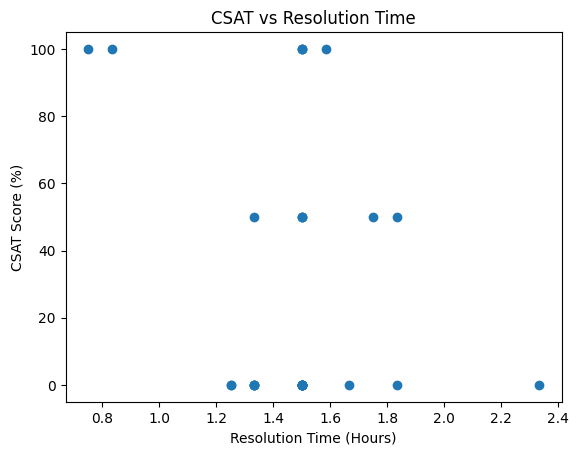

In [ ]:
plt.figure()
plt.scatter(df['Resolution_Time_Hours'], df['CSAT_Score'])
plt.xlabel('Resolution Time (Hours)')
plt.ylabel('CSAT Score (%)')
plt.title('CSAT vs Resolution Time')
plt.show()


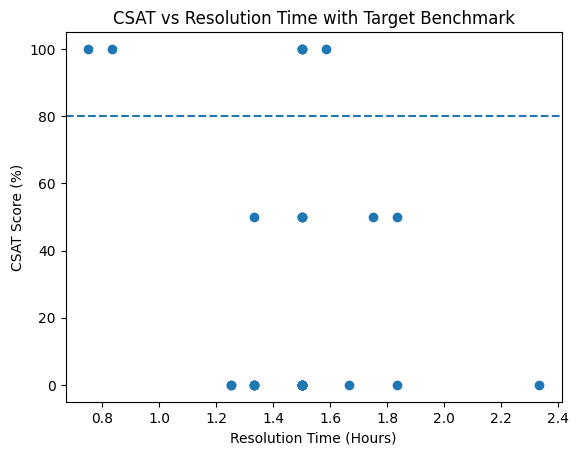

In [ ]:
plt.figure()
plt.scatter(df['Resolution_Time_Hours'], df['CSAT_Score'])
plt.axhline(y=80, linestyle='--')
plt.xlabel('Resolution Time (Hours)')
plt.ylabel('CSAT Score (%)')
plt.title('CSAT vs Resolution Time with Target Benchmark')
plt.show()


A scatter plot was used to examine the relationship between customer satisfaction and resolution time. CSAT scores were derived from ticket sentiment to enable ticket-level analysis. The visualization indicates that tickets resolved faster are more likely to receive positive customer sentiment, while longer resolution times are associated with lower satisfaction scores.

**Category vs Resolution Time (Bottleneck Detection) - BAR CHART**

/tmp/ipython-input-2583043766.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_res_time, x='Category', y='Resolution_Time_Hours', palette='Blues_d')


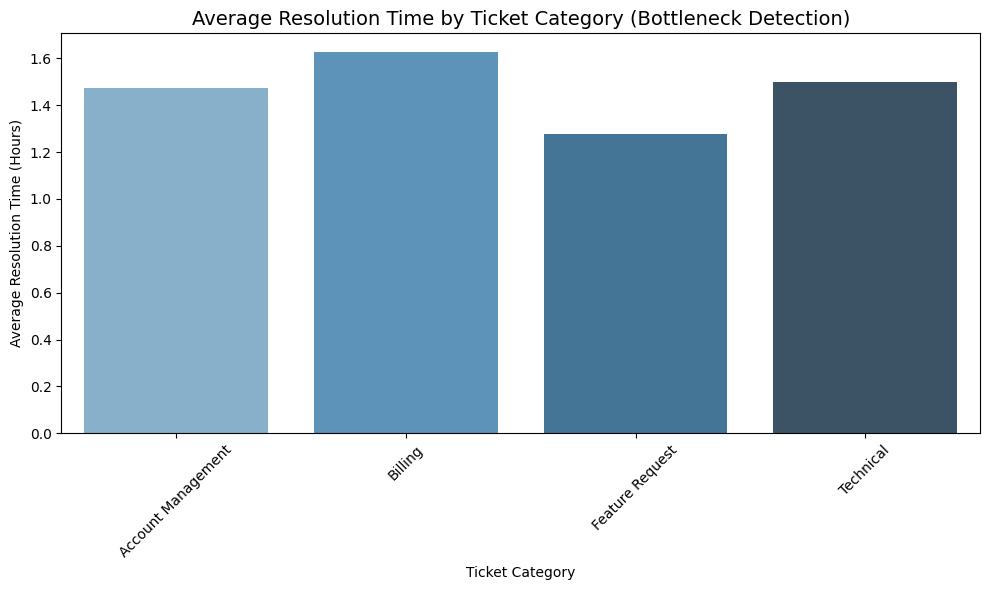

In [ ]:
import seaborn as sns

# Calculate average resolution time per category
category_res_time = df.groupby('Category')['Resolution_Time_Hours'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=category_res_time, x='Category', y='Resolution_Time_Hours', palette='Blues_d')
plt.title('Average Resolution Time by Ticket Category (Bottleneck Detection)', fontsize=14)
plt.xlabel('Ticket Category')
plt.ylabel('Average Resolution Time (Hours)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bar chart showing which categories take longer → detects bottlenecks.

**Agent Workload vs Resolution Time (Performance Balance) - SCATTER PLOT**

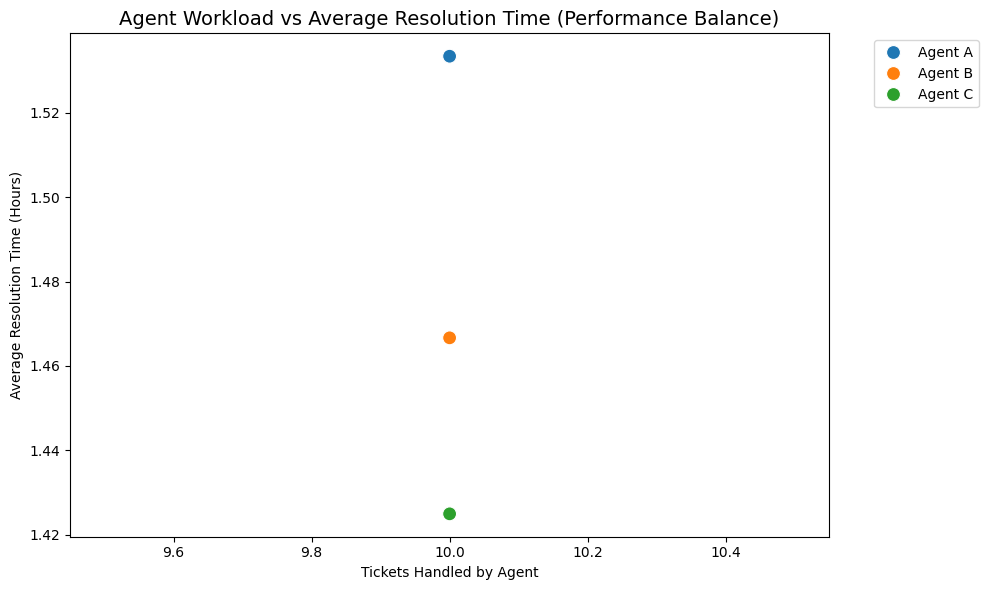

In [ ]:
# Average resolution time per agent
agent_res_time = df.groupby('Agent')['Resolution_Time_Hours'].mean().reset_index()

# Number of tickets handled per agent
agent_ticket_count = df.groupby('Agent')['Ticket ID'].count().reset_index().rename(columns={'Ticket ID':'Ticket_Count'})

# Merge workload and performance
agent_summary = agent_res_time.merge(agent_ticket_count, on='Agent')

plt.figure(figsize=(10,6))
sns.scatterplot(data=agent_summary, x='Ticket_Count', y='Resolution_Time_Hours', hue='Agent', s=100, palette='tab10')
plt.title('Agent Workload vs Average Resolution Time (Performance Balance)', fontsize=14)
plt.xlabel('Tickets Handled by Agent')
plt.ylabel('Average Resolution Time (Hours)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Scatter plot shows each agent’s ticket load vs. average resolution time → highlights performance vs workload balance.

**Priority vs Resolution Time - BAR CHART**

/tmp/ipython-input-3099397445.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=priority_res_time, x='Priority', y='Resolution_Time_Hours', palette='Oranges_d')


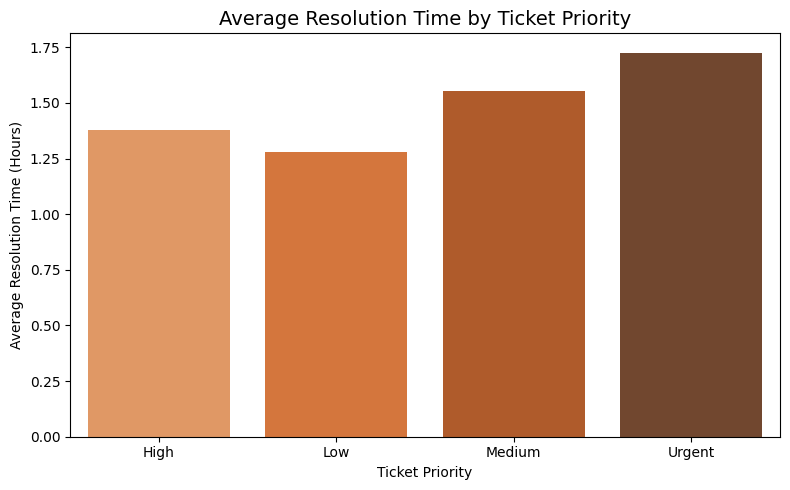

In [ ]:
# Calculate average resolution time per priority
priority_res_time = df.groupby('Priority')['Resolution_Time_Hours'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=priority_res_time, x='Priority', y='Resolution_Time_Hours', palette='Oranges_d')
plt.title('Average Resolution Time by Ticket Priority', fontsize=14)
plt.xlabel('Ticket Priority')
plt.ylabel('Average Resolution Time (Hours)')
plt.tight_layout()
plt.show()

Shows whether High/Medium/Low priority tickets are being resolved efficiently.

Helps detect if SLA rules for priorities are being followed.

Can be used for bottleneck analysis or resource allocation improvements.